In [1]:
%pip install matplotlib pandas pyarrow s3fs

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 11.2 MB 24.6 MB/s eta 0:00:01
     |████████████████████████████████| 39.1 MB 93.4 MB/s eta 0:00:01
     |████████████████████████████████| 965 kB 87.5 MB/s eta 0:00:01
     |████████████████████████████████| 1.1 MB 26.6 MB/s eta 0:00:01
     |████████████████████████████████| 143 kB 101.6 MB/s eta 0:00:01
     |████████████████████████████████| 66 kB 10.8 MB/s eta 0:00:01
     |████████████████████████████████| 9.1 MB 107.5 MB/s eta 0:00:01
     |████████████████████████████████| 77 kB 11.8 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
boto3 1.9.66 requires botocore<1.13.0,>=1.12.66, but you have botocore 1.27.5

Unikalne rekordy: 35
Średnia temperatura: 17.34 °C
Średnie opóźnienie (NRT): 1.23 sekund
Średnie opóźnienie (Batch): 111.55 sekund

Kierunki wiatru w NRT:
S     9
N     6
SE    5
E     4
W     3
NW    3
SW    3
NE    2
Name: wind_str_direction, dtype: int64

Kierunki wiatru w Batch:
S     9
N     6
SE    5
E     4
W     3
NW    3
SW    3
NE    2
Name: wind_str_direction, dtype: int64


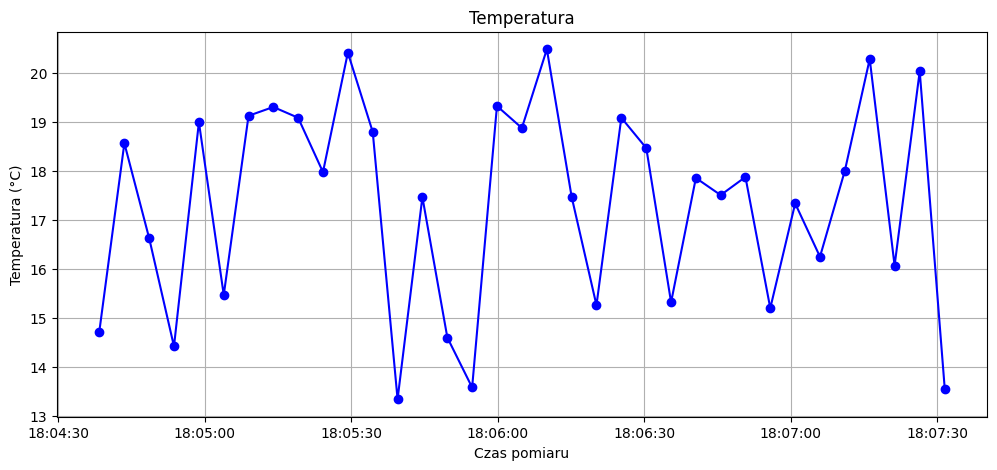

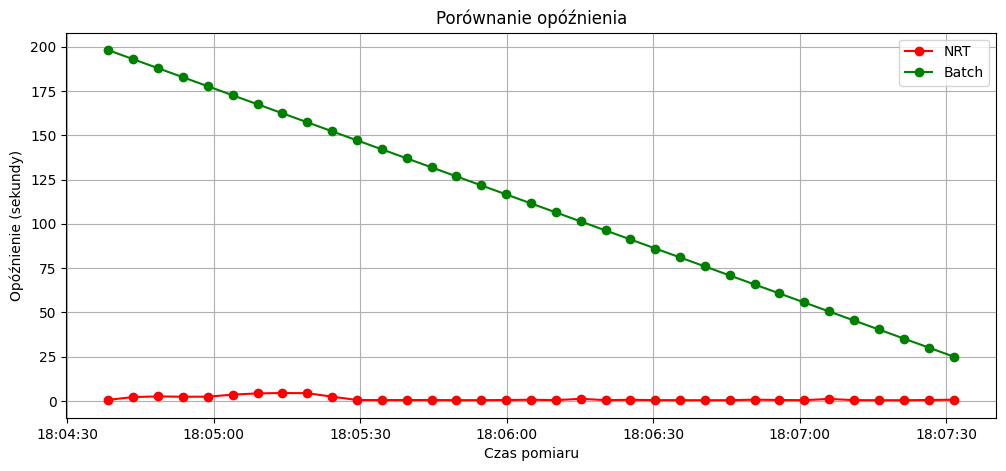

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def classify_direction(direction):
    if direction is None: return "Brak danych"
    elif direction > 337.5: return "N"
    elif direction > 292.5: return "NE"
    elif direction > 247.5: return "E"
    elif direction > 202.5: return "SE"
    elif direction > 157.5: return "S"
    elif direction > 112.5: return "SW"
    elif direction > 67.5: return "W"
    elif direction > 22.5: return "NW"
    else: return "N"

s3_path_nrt = "s3://emr-notebook-as-2137/curated_nrt/"
s3_path_batch = "s3://emr-notebook-as-2137/curated_batch/"

df_nrt = pd.read_parquet(s3_path_nrt)
df_batch = pd.read_parquet(s3_path_batch)

df_nrt = df_nrt.drop_duplicates(subset=["event_time", "station_id"])
df_nrt['event_time'] = pd.to_datetime(df_nrt['event_time'])
df_nrt['processing_time'] = pd.to_datetime(df_nrt['processing_time'])
df_nrt['latency_seconds'] = (df_nrt['processing_time'] - df_nrt['event_time']).dt.total_seconds()
df_nrt['wind_str_direction'] = df_nrt['wind_direction'].apply(classify_direction)
df_nrt = df_nrt.sort_values(by='event_time')

df_batch = df_batch.drop_duplicates(subset=["event_time", "station_id"])
df_batch['event_time'] = pd.to_datetime(df_batch['event_time'])
df_batch['processing_time'] = pd.to_datetime(df_batch['processing_time'])
df_batch['latency_seconds'] = (df_batch['processing_time'] - df_batch['event_time']).dt.total_seconds()
df_batch['wind_str_direction'] = df_batch['wind_direction'].apply(classify_direction)
df_batch = df_batch.sort_values(by='event_time')

avg_temp_nrt = df_nrt['temperature'].mean()
avg_temp_batch = df_batch['temperature'].mean()

avg_latency_nrt = df_nrt['latency_seconds'].mean()
avg_latency_batch = df_batch['latency_seconds'].mean()

print(f"Unikalne rekordy: {len(df_nrt)}")
print(f"Średnia temperatura: {avg_temp_nrt:.2f} °C")
print(f"Średnie opóźnienie (NRT): {avg_latency_nrt:.2f} sekund")
print(f"Średnie opóźnienie (Batch): {avg_latency_batch:.2f} sekund")

print("\nKierunki wiatru:")
print(df_nrt['wind_str_direction'].value_counts())

plt.figure(figsize=(12, 5))

plt.plot(df_nrt['event_time'], df_nrt['temperature'], marker='o', color='blue')

plt.title('Temperatura')
plt.xlabel('Czas pomiaru')
plt.ylabel('Temperatura (°C)')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))

plt.plot(df_nrt['event_time'], df_nrt['latency_seconds'], marker='o', color='red', label='NRT')
plt.plot(df_batch['event_time'], df_batch['latency_seconds'], marker='o', color='green', label='Batch')

plt.title('Porównanie opóźnienia')
plt.xlabel('Czas pomiaru')
plt.ylabel('Opóźnienie (sekundy)')
plt.legend()
plt.grid(True)
plt.show()